In [ ]:
#Importing all required libraries
import numpy as np
import pandas as pd
from copy import deepcopy #To create a safe copy of complex python objects
from torchvision import transforms #imports image transforms(resize,crop,normalize)
from torchvision.models import resnet50,ResNet50_Weights #imports resnet architecture used in tranfer learning
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch #main python library of PyTorch(open-source DL framework) and works with tensors training ml models
import torch.nn as nn #helps to design and organize the layers of neural network
import torch.optim as optim
from PIL import Image #Python Image Loader opens images from the disk
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
#Label mappings for 3 classes(dry,normal,oily)
label_index = {"dry":0,"normal":1,"oily":2} #Maps class names -> numbers
index_label = {0:"dry",1:"normal",2:"oily"} #Reverse mapping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive"
for root,dirs,files in os.walk(path):
  print(root)

/content/drive/MyDrive
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/23A31A05F1  (1)
/content/drive/MyDrive/23A31A05F1 
/content/drive/MyDrive/Skin_DataSet
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/valid
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/valid/oily
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/valid/normal
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/valid/dry
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/train
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/train/oily
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/train/normal
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/train/dry
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/test
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/test/oily
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/test/normal
/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin

In [ ]:
import torch
torch.cuda.get_device_name(0)

'Tesla T4'

In [ ]:
!du -sh "/content/drive/MyDrive/Skin_DataSet"

183M	/content/drive/MyDrive/Skin_DataSet


In [ ]:
!nvidia-smi

Mon Sep 22 14:53:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
def create_dataframe(train_path):
  dd = {"images":[],"labels":[]}
  for i in os.listdir(train_path):#loops through all items(dry,normal,oily)
    if i in label_index:
      label = os.path.join(train_path,i)
      for j in os.listdir(label):
        img = os.path.join(label,j)
        dd["images"].append(img)
        dd["labels"].append(label_index[i])
  return pd.DataFrame(dd)

In [ ]:
train_dataframe = create_dataframe("/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/train")
valid_dataframe = create_dataframe("/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/valid")
test_dataframe = create_dataframe("/content/drive/MyDrive/Skin_DataSet/Oily-Dry-Skin-Types/test")

#Combine all the data and split into train,validation,testing sets
train_dataframe,testing = train_test_split(train_dataframe,random_state=42,test_size=0.2)
valid_dataframe,test_dataframe = train_test_split(testing,random_state=42,test_size=0.5)

In [ ]:
class SkinDetector(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path, label = self.data.iloc[idx, 0], self.data.iloc[idx, 1]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), #randomly crops part of the image and resizes it to 224x224
    transforms.RandomRotation(30), #randomly rotates img
    transforms.RandomHorizontalFlip(), #randomly flips image left to right
    transforms.RandomVerticalFlip(), #randomly flips image top to bottom
    transforms.ColorJitter(
        brightness = 0.2,hue = 0.2,saturation = 0.2,contrast = 0.2
    ), #converts image into equal parametes
    transforms.ToTensor(), #converts image into tensor(multi dimensional arrays)
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std = [0.229,0.224,0.225]
    )
])

In [ ]:
# Create Dataset
train_dataset = SkinDetector(train_dataframe,transform = train_transform)
valid_dataset = SkinDetector(valid_dataframe,transform = valid_transform)
test_dataset = SkinDetector(test_dataframe,transform = valid_transform)

train_Loader = DataLoader(train_dataset,batch_size = 32,shuffle = True) #Loads training data in batches of 32 images
valid_Loader = DataLoader(valid_dataset,batch_size = 32,shuffle = True)
test_Loader = DataLoader(test_dataset,batch_size = 32,shuffle = True)

In [ ]:
#Load pre-trained CNN - ResNet50 Model(Transfer Learning) and fine-tune it
resnet = resnet50(weights = ResNet50_Weights.DEFAULT) #Here we are using pre-trained weights

resnet.fc = nn.Linear(resnet.fc.in_features,3) # A linear(fully connected) layer that takes n number of i/p's and produces 3 o/p's.
                                               # nn - neural network
#Check if Cuda(Compute Unified Device Architecture) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Cuda is a parallel computing platform developed by NVIDIA.Used for GPU acts a super fast processor
                                                                      #for machine learning instead of handlinng graphics
model = deepcopy(resnet).to(device)

#Define loss,optimizier,learning rate scheduler
criterion = nn.CrossEntropyLoss() #Loss measures how wrong the model is.Low loss -> Model is efficient

optimizer = optim.SGD(model.parameters(),lr=0.1)# Optimizer → A tool that updates the weights of a neural network to make the model better by reducing the LOSS.
                                                # SGD (Stochastic Gradient Descent) → Updates weights using small random batches of data instead of the whole dataset.
                                                # lr (learning rate) → Controls how big the update steps are (e.g., weight change = weight - 0.1 × gradient if lr=0.1).

# A scheduler automatically changes the learning rate during training.
# Why? → At first we want big steps (fast learning), later we want smaller steps (fine-tuning carefully).

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

# optimizer → the optimizer whose learning rate we want to adjust.
# step_size=15 → after every 15 epochs, reduce the learning rate
# gamma=0.1   → multiply the current learning rate by 0.1 (make it 10 times smaller)

# Example:
# If initial lr = 0.1
# After 15 epochs → lr = 0.1 * 0.1 = 0.01
# After 30 epochs → lr = 0.01 * 0.1 = 0.001
# After 45 epochs → lr = 0.001 * 0.1 = 0.0001

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s]


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Memory Usage:")
    print("Allocated:", round(torch.cuda.memory_allocated(0)/1024**3,1), "GB")
    print("Cached:   ", round(torch.cuda.memory_reserved(0)/1024**3,1), "GB")


Device in use: cuda
GPU Name: Tesla T4
Memory Usage:
Allocated: 0.1 GB
Cached:    0.1 GB


In [ ]:
best_model = deepcopy(model)
best_arr = 0
train_arr = []
train_loss = []
val_arr = []
val_loss = []

for epoch in range(1,31):
  model.train()

  diff = 0
  total = 0
  arr = 0

  for data,target in train_Loader:#data->Images, target-> labels
    optimizer.zero_grad() #Updates the optimizier value to zero for every epoch.

    data,target = data.to(device),target.to(device)

    out = model(data) #forward-pass using resnet.It stores logits like tensor([1.5, -0.8, 0.3])

    loss = criterion(out,target) #CrossEntropyLoss is used.Compares out o/p with the true value.Returns: loss is a scalar tensor (1 value) → average loss for this batch.

    diff +=  loss.item() #Converts the PyTorch tensor into a Python float.

    arr += (out.argmax(1) == target).sum().item()
    # out.argmax(1) takes the index of the maximum value over the each image in a batch( in 1 dimension).
    # compares with target(labels of each images) and generates [true,false,true,.....].
    # Now, the sum of true values are taken.
    # item() converts the tensor value into python number.

    total += out.size(0) # counts the number of images

    loss.backward() #Backward Propagation
    optimizer.step() #Applies optimizier to get better weights

  train_arr.append(arr/total)
  train_loss.append(diff/total)

    #Validation Step

  model.eval()

  diff = 0
  total = 0
  arr = 0
  with torch.no_grad():
    for data,target in valid_Loader:
      data, target = data.to(device),target.to(device)

      out = model(data)

      loss = criterion(out,target)

      diff += loss.item()

      arr += (out.argmax(1)==target).sum().item()

      total += out.size(0)

  val_arr.append(arr/total)
  val_loss.append(diff/total)

  if val_arr[-1] > best_arr:
      best_arr = val_arr[-1]
      best_model = deepcopy(model)

  #Scheduler Step
  scheduler.step()

  print(f"Epoch {epoch}, "
          f"Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_arr[-1]:.4f}, "
          f"Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_arr[-1]:.4f}")

Epoch 1, Train Loss: 0.0336, Train Acc: 0.4359, Val Loss: 0.0336, Val Acc: 0.4281
Epoch 2, Train Loss: 0.0323, Train Acc: 0.4813, Val Loss: 0.0317, Val Acc: 0.5432
Epoch 3, Train Loss: 0.0304, Train Acc: 0.5250, Val Loss: 0.0309, Val Acc: 0.5108
Epoch 4, Train Loss: 0.0292, Train Acc: 0.5398, Val Loss: 0.0279, Val Acc: 0.5755
Epoch 5, Train Loss: 0.0274, Train Acc: 0.5947, Val Loss: 0.0358, Val Acc: 0.5180
Epoch 6, Train Loss: 0.0263, Train Acc: 0.6118, Val Loss: 0.0271, Val Acc: 0.6295
Epoch 7, Train Loss: 0.0249, Train Acc: 0.6500, Val Loss: 0.0259, Val Acc: 0.5971
Epoch 8, Train Loss: 0.0234, Train Acc: 0.6662, Val Loss: 0.0239, Val Acc: 0.7158
Epoch 9, Train Loss: 0.0215, Train Acc: 0.6946, Val Loss: 0.0235, Val Acc: 0.6942
Epoch 10, Train Loss: 0.0206, Train Acc: 0.7193, Val Loss: 0.0222, Val Acc: 0.7302
Epoch 11, Train Loss: 0.0186, Train Acc: 0.7463, Val Loss: 0.0158, Val Acc: 0.7986
Epoch 12, Train Loss: 0.0183, Train Acc: 0.7472, Val Loss: 0.0314, Val Acc: 0.6727
Epoch 13, Tra

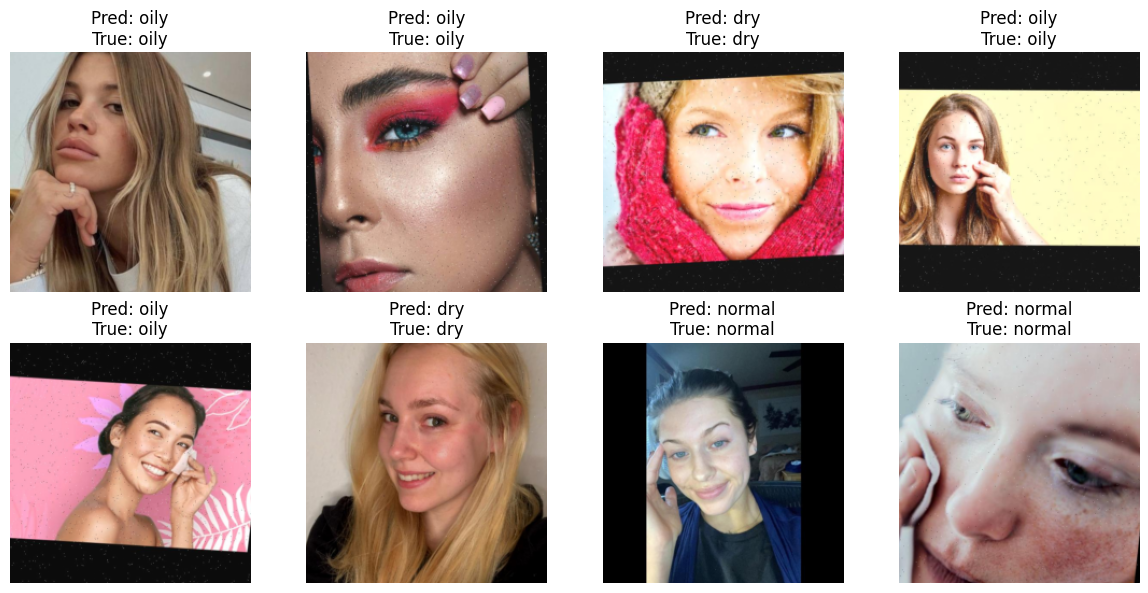

In [ ]:
import matplotlib.pyplot as plt

model.eval()
label_map = {0: "dry", 1: "normal", 2: "oily"}  # Updated for 3 classes

# Recreate the DataLoader iterator
data_iter = iter(valid_Loader)
images, labels = next(data_iter)

# Move to device
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Move to CPU for plotting
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(12, 6))
for idx in range(8):  # Show 8 images
    img = images[idx].permute(1, 2, 0)

    # Unnormalize (using mean/std from transforms)
    img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    img = img.clamp(0, 1)

    plt.subplot(2, 4, idx + 1)
    plt.imshow(img.numpy())
    plt.title(f"Pred: {label_map[preds[idx].item()]}\nTrue: {label_map[labels[idx].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = best_model
correct = 0
total = 0
test_loss = 0
with torch.no_grad():
  for data, target in test_Loader:
    data, target = data.to(device),target.to(device)

    out = model(data)
    loss = criterion(out,target)

    test_loss += loss.item()
    correct += (out.argmax(1)==target).sum().item()
    total += out.size(0)
test_acc = correct/total
test_loss = test_loss/total
print(f"Testing Accuracy: {test_acc:.4f}, Testing Loss: {test_loss:.4f}")

Testing Accuracy: 0.9029, Testing Loss: 0.0097


In [ ]:
# Average Training Accuracy
avg_train_acc = sum(train_arr) / len(train_arr)

# Average Validation Accuracy
avg_val_acc = sum(val_arr) / len(val_arr)

print(f"Average Training Accuracy: {avg_train_acc:.4f}")
print(f"Average Validation Accuracy: {avg_val_acc:.4f}")


Average Training Accuracy: 0.7645
Average Validation Accuracy: 0.7801


Test Accuracy: 0.9029


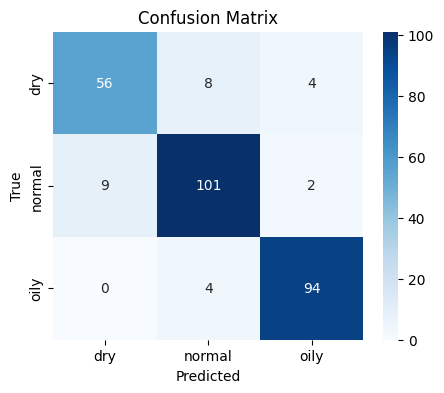

Classification Report:
               precision    recall  f1-score   support

         dry       0.86      0.82      0.84        68
      normal       0.89      0.90      0.90       112
        oily       0.94      0.96      0.95        98

    accuracy                           0.90       278
   macro avg       0.90      0.89      0.90       278
weighted avg       0.90      0.90      0.90       278



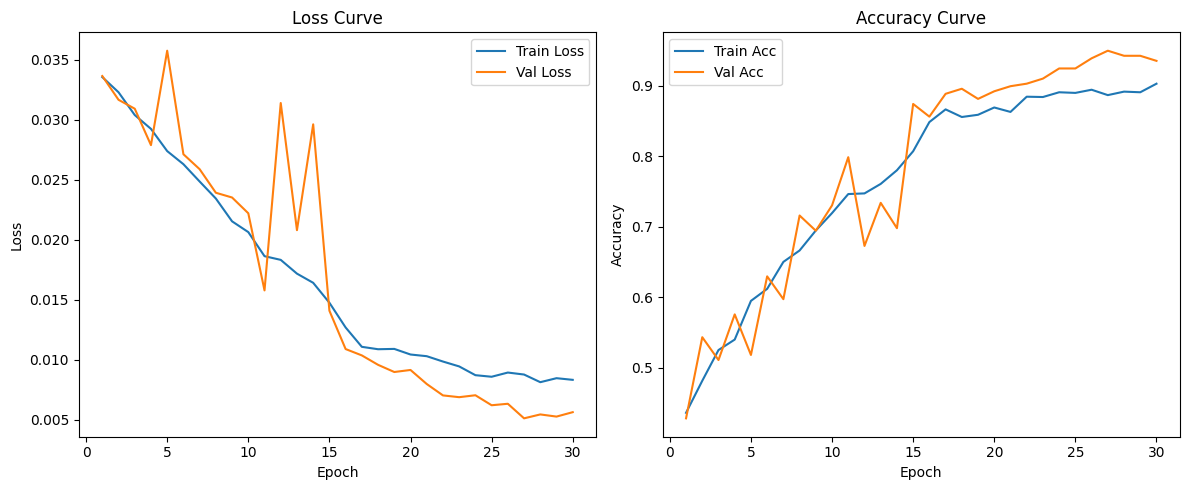

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- Evaluate on Test Set ---
model.eval()
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_targets = []
all_preds = []

with torch.no_grad():
    for data, targets in test_dl:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        preds = outputs.argmax(1)
        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# --- Accuracy ---
test_acc = accuracy_score(all_targets, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["dry","normal", "oily"], yticklabels=["dry","normal","oily"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# --- Classification Report ---
cr = classification_report(all_targets, all_preds, target_names=["dry","normal","oily"])
print("Classification Report:\n", cr)

# --- Training/Validation Loss and Accuracy Curves ---
epochs = range(1, len(train_loss)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_arr, label='Train Acc')
plt.plot(epochs, val_arr, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch

# Save the full model (trusted source)
torch.save(model, "skin_type_detector_app_full.pth")
print("✅ Full model saved")


✅ Full model saved


In [ ]:
import torch

# Load the full model safely
model = torch.load("skin_type_detector_app_full.pth", map_location=torch.device("cpu"), weights_only=False)
model.eval()
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
import torch
import cv2
import numpy as np
import requests

def load_online_image(url, img_size=(224,224)):
    try:
        # Use requests to get the image content
        resp = requests.get(url, stream=True)
        if resp.status_code != 200:
            raise ValueError(f"Image download failed with status code {resp.status_code}")

        # Convert to numpy array
        img_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        if img is None:
            raise ValueError("Failed to decode image. Make sure URL points to a valid image file.")

        # Resize & preprocess
        img = cv2.resize(img, img_size)
        img = img / 255.0
        img = np.transpose(img, (2,0,1))
        img = np.expand_dims(img, axis=0)
        img = torch.tensor(img, dtype=torch.float32)
        return img

    except Exception as e:
        print("Error loading image:", e)
        return None

# Example of a working direct image URL
image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
img = load_online_image(image_url)

if img is not None:
    with torch.no_grad():
        output = model(img)
        predicted_class = torch.argmax(output, dim=1).item()
    print("Predicted Skin Type:", labels[predicted_class])
else:
    print("Failed to load image.")


Predicted Skin Type: Dry


In [ ]:
import torch

# Save the full model
torch.save(model, "skin_type_detector_app_full.pth")
print("✅ Full model saved as skin_type_detector_app_full.pth")


✅ Full model saved as skin_type_detector_app_full.pth


In [ ]:
from google.colab import files
files.download("skin_type_detector_app_full.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "C:\\Users\\Teja\\Downloads\\Skin Type Detector\\backend\\app\\skin_type_detector_app_full.pth"


Mounted at /content/drive


In [ ]:
import os
print(os.path.exists(MODEL_PATH))

False


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving skin_type_detector_app_full.pth to skin_type_detector_app_full.pth


In [ ]:
MODEL_PATH = "/content/skin_type_detector_app_full.pth"


In [ ]:
import torch
from torchvision.models import resnet50
import torch.nn as nn

# Path to saved model
MODEL_PATH = "/content/skin_type_detector_app_full.pth"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Option 1: Try to load as full model (since it was saved with the whole object)
try:
    model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    print("✅ Loaded full model successfully!")
except Exception as e:
    print("⚠️ Full model load failed, falling back to state_dict:", e)

    # Option 2: If above fails, load only the state_dict
    model = resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 3)  # 3 classes
    state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(state_dict)

# Put model on device
model.to(device)
model.eval()

✅ Loaded full model successfully!


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
from google.colab import files

# Open file picker to upload
uploaded = files.upload()


Saving women_oily to women_oily


In [ ]:
from PIL import Image
from torchvision import transforms

# Define preprocessing (must match training preprocessing!)
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # resize to match ResNet input
    transforms.ToTensor(),           # convert to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet normalization (if you trained with it)
        std=[0.229, 0.224, 0.225]
    )
])

# Load a test image
img_path = "/content/women_oily"
  # <-- replace with your test image
img = Image.open(img_path).convert("RGB")

# Preprocess
input_tensor = transform(img).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

# Map prediction index to class name
class_names = ["Dry", "Normal", "Oily"]
print(f"Prediction: {class_names[predicted_class]} (confidence: {probs[0][predicted_class]:.2f})")


Prediction: Oily (confidence: 1.00)


In [ ]:
from google.colab import files

# Open file picker to upload
uploaded = files.upload()

Saving Screenshot 2025-09-29 212848.png to Screenshot 2025-09-29 212848.png


In [ ]:
from PIL import Image
from torchvision import transforms

# Define preprocessing (must match training preprocessing!)
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # resize to match ResNet input
    transforms.ToTensor(),           # convert to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet normalization (if you trained with it)
        std=[0.229, 0.224, 0.225]
    )
])

# Load a test image
img_path = "/content/Screenshot 2025-09-29 212848.png"
  # <-- replace with your test image
img = Image.open(img_path).convert("RGB")

# Preprocess
input_tensor = transform(img).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

# Map prediction index to class name
class_names = ["Dry", "Normal", "Oily"]
print(f"Prediction: {class_names[predicted_class]} (confidence: {probs[0][predicted_class]:.2f})")

Prediction: Dry (confidence: 0.40)


In [ ]:
from google.colab import files

# Open file picker to upload
uploaded = files.upload()

Saving Screenshot 2025-09-29 213023.png to Screenshot 2025-09-29 213023.png


In [ ]:
from PIL import Image
from torchvision import transforms

# Define preprocessing (must match training preprocessing!)
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # resize to match ResNet input
    transforms.ToTensor(),           # convert to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # ImageNet normalization (if you trained with it)
        std=[0.229, 0.224, 0.225]
    )
])

# Load a test image
img_path = "/content/Screenshot 2025-09-29 213023.png"
  # <-- replace with your test image
img = Image.open(img_path).convert("RGB")

# Preprocess
input_tensor = transform(img).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

# Map prediction index to class name
class_names = ["Dry", "Normal", "Oily"]
print(f"Prediction: {class_names[predicted_class]} (confidence: {probs[0][predicted_class]:.2f})")

Prediction: Normal (confidence: 0.84)
